<a href="https://colab.research.google.com/github/JahnaviCh25/Predicting-Stock-Prices-with-Artificial-Neural-Networks/blob/main/Programming_Assignment_02_INFO5505_Jahnavi_Chintakindi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Done By
Jahanvi Chintakindi
11711379


**In this assignment, you will learn how to implement the stock prediction model using neural networks step by step practically**. We will start with a detailed explanation of neural networks, including the essential components (layers, activations, feedforward, and backpropagation) and transition to deep learning. We then move on to implementations from scratch with scikit-learn and TensorFlow. You also will learn about ways to avoid overfitting, such as dropout and early stopping. Finally, you will apply what we covered previously to solve our stock price prediction problem. You might use the attached two datasets.

Importing Libraries: The script begins by importing necessary libraries such as numpy, pandas, and scikit-learn.

In [ ]:
import numpy as np
import pandas as pd
from sklearn import preprocessing, datasets

Activation Functions: Two functions are defined here - sigmoid() and sigmoid_derivative(). These are typical activation functions used in neural networks.

In [ ]:
def sigmoid(z):
    return 1.0 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    return sigmoid(z) * (1.0 - sigmoid(z))

Training Function: The train() function is defined to train a neural network model. It implements the backpropagation algorithm to update the weights and biases of the network

In [49]:
def train(X, y, n_hidden, learning_rate, n_iter):
    m, n_input = X.shape
    W1 = np.random.randn(n_input, n_hidden)
    b1 = np.zeros((1, n_hidden))
    W2 = np.random.randn(n_hidden, 1)
    b2 = np.zeros((1, 1))

    for i in range(1, n_iter + 1):
        Z2 = np.matmul(X, W1) + b1
        A2 = sigmoid(Z2)
        Z3 = np.matmul(A2, W2) + b2
        A3 = Z3
        dZ3 = A3 - y
        dW2 = np.matmul(A2.T, dZ3)
        db2 = np.sum(dZ3, axis=0, keepdims=True)
        dZ2 = np.matmul(dZ3, W2.T) * sigmoid_derivative(Z2)
        dW1 = np.matmul(X.T, dZ2)
        db1 = np.sum(dZ2, axis=0)
        W2 = W2 - learning_rate * dW2 / m
        b2 = b2 - learning_rate * db2 / m
        W1 = W1 - learning_rate * dW1 / m
        b1 = b1 - learning_rate * db1 / m

        if i % 100 == 0:
            cost = np.mean((y - A3) ** 2)
            print('Iteration %i, training loss: %f' % (i, cost))

    model = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
    return model


Reading Data: The script reads in data from a URL (Boston dataset) using pandas. It then preprocesses the data using sklearn's StandardScaler().

In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
boston_data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
boston_target = raw_df.values[1::2, 2]

In [ ]:
# boston = datasets.load_boston()

# need to fix the datasets
num_test = 10

scaler = preprocessing.StandardScaler()
X_train = boston_data[:-num_test, :]
X_train = scaler.fit_transform(X_train)
y_train = boston_target[:-num_test].reshape(-1, 1)
X_test = boston_data[-num_test:, :]
X_test = scaler.transform(X_test)
y_test = boston_target[-num_test:]

n_hidden = 20
learning_rate = 0.1
n_iter = 2000
model = train(X_train, y_train, n_hidden, learning_rate, n_iter)


Iteration 100, training loss: 13.164253
Iteration 200, training loss: 9.186919
Iteration 300, training loss: 7.900228
Iteration 400, training loss: 7.090176
Iteration 500, training loss: 6.445184
Iteration 600, training loss: 5.901563
Iteration 700, training loss: 5.451536
Iteration 800, training loss: 5.103862
Iteration 900, training loss: 4.829456
Iteration 1000, training loss: 4.602742
Iteration 1100, training loss: 4.405868
Iteration 1200, training loss: 4.230541
Iteration 1300, training loss: 4.074683
Iteration 1400, training loss: 3.937309
Iteration 1500, training loss: 3.816215
Iteration 1600, training loss: 3.708396
Iteration 1700, training loss: 3.609280
Iteration 1800, training loss: 3.513893
Iteration 1900, training loss: 3.422316
Iteration 2000, training loss: 3.337416


Training the Neural Network: A neural network with one hidden layer is trained using the train() function defined earlier.

In [ ]:
# a prediction function to use the values from the model
def predict(x, model):
    W1 = model['W1']
    b1 = model['b1']
    W2 = model['W2']
    b2 = model['b2']
    A2 = sigmoid(np.matmul(x, W1) + b1)
    A3 = np.matmul(A2, W2) + b2
    return A3

Prediction: The trained model is then used to make predictions on the test data.

In [ ]:
# finds the data test vs the current model to check accuracy
predictions = predict(X_test, model)

In [ ]:
# print predictions and ground truths to compare
print(predictions)
print(y_test)

[[15.4224854 ]
 [19.49432748]
 [21.87993154]
 [19.77386414]
 [21.65355844]
 [29.75834113]
 [25.34057733]
 [33.63694031]
 [32.31797514]
 [25.65981378]]
[19.7 18.3 21.2 17.5 16.8 22.4 20.6 23.9 22.  11.9]


2)  Implementing neural networks with scikit-learn

Alternative Approaches: The script also demonstrates alternative ways of training neural networks using scikit-learn's MLPRegressor and TensorFlow/Keras.

In [ ]:
from sklearn.neural_network import MLPRegressor

nn_scikit = MLPRegressor(hidden_layer_sizes=(16, 8),
                         activation='relu', solver='adam',
                         learning_rate_init=0.001,
                         random_state=42, max_iter=2000)

Feature Engineering: There's a part of the code that deals with feature engineering. It reads in a CSV file, generates features from the raw data, preprocesses it, and prepares it for training.

In [ ]:
nn_scikit.fit(X_train, y_train)
predictions = nn_scikit.predict(X_test)
print(predictions)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1623: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[16.79582331 18.55538023 21.07961496 19.21362606 18.50955771 23.5608387
 22.27916529 27.11909153 24.70251262 22.05522035]


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print(np.mean((y_test - predictions) ** 2))

13.933482332708795


3) Implementing neural networks with TensorFlow

Training and Testing: The script then splits the data into training and testing sets, scales the features, trains a neural network model, and evaluates its performance.

In [ ]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(units=20, activation='relu'),
    keras.layers.Dense(units=8, activation='relu'),
    keras.layers.Dense(units=1)
])

In [ ]:
model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(0.02))

In [ ]:
model.fit(X_train, y_train, epochs=300)


Epoch 1/300
16/16 [==============================] - 1s 2ms/step - loss: 359.3243
Epoch 2/300
16/16 [==============================] - 0s 2ms/step - loss: 88.7908
Epoch 3/300
16/16 [==============================] - 0s 2ms/step - loss: 36.2717
Epoch 4/300
16/16 [==============================] - 0s 2ms/step - loss: 25.0647
Epoch 5/300
16/16 [==============================] - 0s 2ms/step - loss: 20.1522
Epoch 6/300
16/16 [==============================] - 0s 2ms/step - loss: 17.0847
Epoch 7/300
16/16 [==============================] - 0s 2ms/step - loss: 14.6562
Epoch 8/300
16/16 [==============================] - 0s 2ms/step - loss: 14.3858
Epoch 9/300
16/16 [==============================] - 0s 2ms/step - loss: 13.0121
Epoch 10/300
16/16 [==============================] - 0s 2ms/step - loss: 11.6561
Epoch 11/300
16/16 [==============================] - 0s 2ms/step - loss: 11.3595
Epoch 12/300
16/16 [==============================] - 0s 2ms/step - loss: 11.4751
Epoch 13/300
16/16 [====

In [ ]:
predictions = model.predict(X_test)[:, 0]
print(predictions)

1/1 [==============================] - 0s 85ms/step
[18.039768 19.750051 22.222143 20.118845 19.616112 30.540197 25.42475
 33.56002  30.77857  24.653776]


In [ ]:
print(np.mean((y_test - predictions) ** 2))


44.32717457654006


4) Picking the right activation functions

Hyperparameter Tuning: The script performs hyperparameter tuning by trying different combinations of hyperparameters using TensorFlow's HParams API.

In [ ]:
# This is using the keras model and tensorflow, specifically with dropout to keep overfitting low

model = keras.Sequential([
    keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    keras.layers.Dense(units=1)
])

Acquiring data and generating features

In [ ]:
# next requires data set. Pause. Use direct path because it is proper for me
mydata = pd.read_csv('/content/drive/MyDrive/5505 Assignments/20051201_20051210.csv',
                     index_col='Date')
mydata

,Open,High,Low,Close,Volume
Date,,,,,
2005-12-01,10806.0,10934.9,10806.0,10912.6,256932865
2005-12-02,10912.0,10921.4,10861.7,10877.5,214888854
2005-12-05,10877.0,10877.0,10810.7,10835.0,237430947
2005-12-06,10835.4,10936.2,10835.4,10856.9,264721465
2005-12-07,10856.9,10868.1,10764.0,10810.9,243543206
2005-12-08,10808.4,10847.2,10729.7,10755.1,253313750
2005-12-09,10751.8,10806.0,10729.9,10778.6,238907145


In [ ]:
# all these following definitions are for handling the data and organizing it
def add_original_feature(df, df_new):
    df_new['open'] = df['Open']
    df_new['open_1'] = df['Open'].shift(1)
    df_new['close_1'] = df['Close'].shift(1)
    df_new['high_1'] = df['High'].shift(1)
    df_new['low_1'] = df['Low'].shift(1)
    df_new['volume_1'] = df['Volume'].shift(1)

In [ ]:
def add_avg_price(df, df_new):
    df_new['avg_price_5'] = df['Close'].rolling(5).mean().shift(1)
    df_new['avg_price_30'] = df['Close'].rolling(21).mean().shift(1)
    df_new['avg_price_365'] = df['Close'].rolling(252).mean().shift(1)
    df_new['ratio_avg_price_5_30'] = df_new['avg_price_5'] / df_new['avg_price_30']
    df_new['ratio_avg_price_5_365'] = df_new['avg_price_5'] / df_new['avg_price_365']
    df_new['ratio_avg_price_30_365'] = df_new['avg_price_30'] / df_new['avg_price_365']


In [ ]:
def add_avg_volume(df, df_new):
    df_new['avg_volume_5'] = df['Volume'].rolling(5).mean().shift(1)
    df_new['avg_volume_30'] = df['Volume'].rolling(21).mean().shift(1)
    df_new['avg_volume_365'] = df['Volume'].rolling(252).mean().shift(1)
    df['ratio_avg_volume_5_30'] = df_new['avg_volume_5'] / df_new['avg_volume_30']
    df['ratio_avg_volume_5_365'] = df_new['avg_volume_5'] / df_new['avg_volume_365']
    df['ratio_avg_volume_30_365'] = df_new['avg_volume_30'] / df_new['avg_volume_365']


In [ ]:
def add_std_price(df, df_new):
    df_new['std_price_5'] = df['Volume'].rolling(5).std().shift(1)
    df_new['std_price_30'] = df['Volume'].rolling(21).std().shift(1)
    df_new['std_price_365'] = df['Volume'].rolling(252).std().shift(1)
    df_new['ratio_std_volume_5_30'] = df_new['std_price_5'] / df_new['std_price_30']
    df_new['ratio_std_volume_5_365'] = df_new['std_price_5'] / df_new['std_price_365']
    df_new['ratio_std_volume_30_365'] = df_new['std_price_30'] / df_new['std_price_365']


In [ ]:
def add_std_volume(df, df_new):
    df_new['std_volume_5'] = df['Volume'].rolling(5).std().shift(1)
    df_new['std_volume_30'] = df['Volume'].rolling(21).std().shift(1)
    df_new['std_volume_365'] = df['Volume'].rolling(252).std().shift(1)
    df_new['ratio_std_volume_5_30'] = df_new['std_volume_5'] / df_new['std_volume_30']
    df_new['ratio_std_volume_5_365'] = df_new['std_volume_5'] / df_new['std_volume_365']
    df_new['ratio_std_volume_30_365'] = df_new['std_volume_30'] / df_new['std_volume_365']


In [ ]:
def add_return_feature(df, df_new):
    df_new['return_1'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)).shift(1)
    df_new['return_5'] = ((df['Close'] - df['Close'].shift(5)) / df['Close'].shift(5)).shift(1)
    df_new['return_30'] = ((df['Close'] - df['Close'].shift(21)) / df['Close'].shift(21)).shift(1)
    df_new['return_365'] = ((df['Close'] - df['Close'].shift(252)) / df['Close'].shift(252)).shift(1)
    df_new['moving_avg_5'] = df_new['return_1'].rolling(5).mean().shift(1)
    df_new['moving_avg_30'] = df_new['return_1'].rolling(21).mean().shift(1)
    df_new['moving_avg_365'] = df_new['return_1'].rolling(252).mean().shift(1)



In [ ]:
def generate_features(df):
    df_new = pd.DataFrame()
    add_original_feature(df, df_new)
    add_avg_price(df, df_new)
    add_avg_volume(df, df_new)
    add_std_price(df, df_new)
    add_std_volume(df, df_new)
    add_return_feature(df, df_new)
    df_new['close'] = df['Close']
    df_new = df_new.dropna(axis=0)
    return df_new


In [ ]:
data_raw = pd.read_csv('/content/drive/MyDrive/5505 Assignments/19880101_20191231.csv',
                       index_col='Date')
data = generate_features(data_raw)

print(data.round(decimals=3).head(5))


              open  open_1  close_1  high_1   low_1    volume_1  avg_price_5  \
Date                                                                           
1989-01-04  2146.6  2168.4   2144.6  2168.4  2127.1  17302883.0      2165.00   
1989-01-05  2177.7  2146.6   2177.7  2183.4  2146.6  15714720.0      2168.00   
1989-01-06  2190.5  2177.7   2190.5  2205.2  2173.0  20303094.0      2172.82   
1989-01-09  2194.3  2190.5   2194.3  2213.8  2182.3  16494441.0      2175.14   
1989-01-10  2199.5  2194.3   2199.5  2209.1  2185.0  18410324.0      2181.32   

            avg_price_30  avg_price_365  ratio_avg_price_5_30  ...  \
Date                                                           ...   
1989-01-04      2150.624       2062.113                 1.007  ...   
1989-01-05      2154.690       2062.668                 1.006  ...   
1989-01-06      2157.867       2063.218                 1.007  ...   
1989-01-09      2160.005       2064.341                 1.007  ...   
1989-01-10      216

Training a simple neural network

In [ ]:
# setting up the training and test boundaries and data
start_train = '1988-01-01'
end_train = '2018-12-31'
start_test = '2019-01-01'
end_test = '2019-12-31'
data_train = data.loc[start_train:end_train]
X_train = data_train.drop('close', axis=1).values
y_train = data_train['close'].values
data_test = data.loc[start_test:end_test]
X_test = data_test.drop('close', axis=1).values
y_test = data_test['close'].values


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:

X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)


In [ ]:

predictions = model.predict(X_scaled_test)


8/8 [==============================] - 0s 2ms/step


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(units=32, activation='relu'),
    Dense(units=1)
])

In [ ]:
model.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(0.1))


In [ ]:
model.fit(X_scaled_train, y_train, epochs=100, verbose=True)


Epoch 1/100
237/237 [==============================] - 1s 2ms/step - loss: 34345516.0000
Epoch 2/100
237/237 [==============================] - 0s 2ms/step - loss: 2244568.7500
Epoch 3/100
237/237 [==============================] - 0s 2ms/step - loss: 264148.3125
Epoch 4/100
237/237 [==============================] - 0s 2ms/step - loss: 84728.4531
Epoch 5/100
237/237 [==============================] - 1s 3ms/step - loss: 44050.5742
Epoch 6/100
237/237 [==============================] - 1s 2ms/step - loss: 31998.1016
Epoch 7/100
237/237 [==============================] - 1s 3ms/step - loss: 24249.2832
Epoch 8/100
237/237 [==============================] - 1s 2ms/step - loss: 21837.8027
Epoch 9/100
237/237 [==============================] - 1s 2ms/step - loss: 21835.6016
Epoch 10/100
237/237 [==============================] - 1s 3ms/step - loss: 20086.8223
Epoch 11/100
237/237 [==============================] - 0s 2ms/step - loss: 24921.0020
Epoch 12/100
237/237 [========================

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# printing of values to show accuracy
print(f'MSE: {mean_squared_error(y_test, predictions):.3f}')
print(f'MAE: {mean_absolute_error(y_test, predictions):.3f}')
print(f'R^2: {r2_score(y_test, predictions):.3f}')


MSE: 697015021.846
MAE: 26379.043
R^2: -599.503


Fine-tuning the neural network

In [ ]:
from tensorboard.plugins.hparams import api as hp


In [ ]:
HP_HIDDEN = hp.HParam('hidden_size', hp.Discrete([64, 32, 16]))
HP_EPOCHS = hp.HParam('epochs', hp.Discrete([300, 1000]))
HP_LEARNING_RATE = hp.HParam('learning_rate', hp.RealInterval(0.01, 0.4))


In [ ]:
def train_test_model(hparams, logdir):
    model = Sequential([
        Dense(units=hparams[HP_HIDDEN],
              activation='relu'),
        Dense(units=1)
    ])
    model.compile(loss='mean_squared_error',
                  optimizer=tf.keras.optimizers.Adam(hparams[HP_LEARNING_RATE]),
                  metrics=['mean_squared_error'])
    model.fit(X_scaled_train, y_train,
              validation_data=(X_scaled_test, y_test),
              epochs=hparams[HP_EPOCHS], verbose=False,
              callbacks=[
                  tf.keras.callbacks.TensorBoard(logdir),
                  hp.KerasCallback(logdir, hparams),
                  tf.keras.callbacks.EarlyStopping(
                      monitor='val_loss', min_delta=0,
                      patience=200, verbose=0,
                      mode='auto',
                  )
              ],
              )
    _, mse = model.evaluate(X_scaled_test, y_test)
    pred = model.predict(X_scaled_test)
    r2 = r2_score(y_test, pred)
    return mse, r2


In [ ]:
def run(hparams, logdir):
    with tf.summary.create_file_writer(logdir).as_default():
        hp.hparams_config(
            hparams=[HP_HIDDEN, HP_EPOCHS,
                     HP_LEARNING_RATE],
            metrics=[hp.Metric('mean_squared_error', display_name='mse'),
                     hp.Metric('r2', display_name='r2')],
        )
        mse, r2 = train_test_model(hparams, logdir)
        tf.summary.scalar('mean_squared_error', mse, step=1)
        tf.summary.scalar('r2', r2, step=1)


In [ ]:
session_num = 0
for hidden in HP_HIDDEN.domain.values:
    for epochs in HP_EPOCHS.domain.values:
        for learning_rate in tf.linspace(HP_LEARNING_RATE.domain.min_value,
                                         HP_LEARNING_RATE.domain.max_value,
                                         5):
            hparams = {
                HP_HIDDEN: hidden,
                HP_EPOCHS: epochs,
                HP_LEARNING_RATE:
                    float("%.2f" % float(learning_rate)),
            }
            run_name = "run-%d" % session_num
            print('--- Starting trial: %s' % run_name)
            print({h.name: hparams[h] for h in hparams})
            run(hparams, 'logs/hparams_tuning/' + run_name)
            session_num += 1


--- Starting trial: run-0
{'hidden_size': 16, 'epochs': 300, 'learning_rate': 0.01}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-1
{'hidden_size': 16, 'epochs': 300, 'learning_rate': 0.11}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-2
{'hidden_size': 16, 'epochs': 300, 'learning_rate': 0.21}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-3
{'hidden_size': 16, 'epochs': 300, 'learning_rate': 0.3}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-4
{'hidden_size': 16, 'epochs': 300, 'learning_rate': 0.4}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-5
{'hidden_size': 16, 'epochs': 1000, 'learning_rate': 0.01}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-6
{'hidden_size': 16, 'epochs': 1000, 'learning_rate': 0.11}
8/8 [==============================] - 0s 2ms/step
--- Starting trial: run-7
{'hidden_size': 16, 'epochs':

In [46]:
model = Sequential([
    Dense(units=64, activation='relu'),
    Dense(units=1)
])
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam(0.3))
model.fit(X_scaled_train, y_train, epochs=1000, verbose=False)
predictions = model.predict(X_scaled_test)[:, 0]


8/8 [==============================] - 0s 2ms/step


Plotting Results: Finally, the script plots the true values against the predicted values.

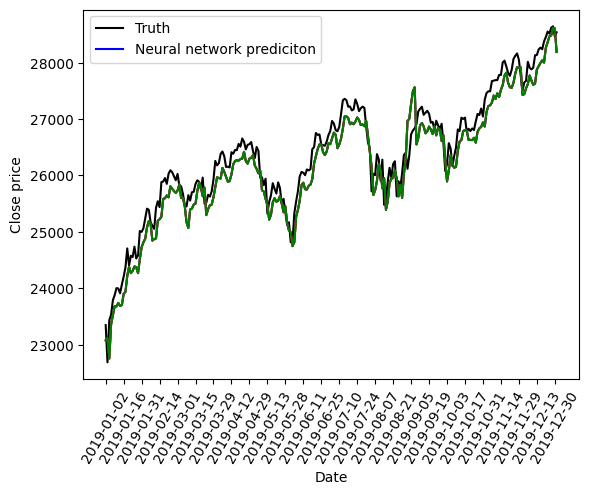

In [48]:
# plotting the data found
import matplotlib.pyplot as plt

plt.plot(data_test.index, y_test, c='k')
plt.plot(data_test.index, predictions, c='b')
plt.plot(data_test.index, predictions, c='r')
plt.plot(data_test.index, predictions, c='g')
plt.xticks(range(0, 252, 10), rotation=60)
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend(['Truth', 'Neural network prediciton'])
plt.show()

Summary
In this assignment, we worked on the stock prediction project again, but with neural networks this time. We started with a detailed explanation of neural networks, including the essential components (layers, activations, feedforward, and backpropagation), and transitioned to DL. We moved on to implementations from scratch with scikit-learn and TensorFlow. You also learned about ways to avoid overfitting, such as dropout and early stopping. Finally, we applied what we covered previously to solve our stock price prediction problem.